In [1]:
# ============================================================
# APL Logistics — Delivery Performance Analysis
# Global Supply Chain Operations | EDA Report
# Dataset : APL_Logistics.csv
# Records : 1,80,519
# Columns : 40
# ============================================================

print("📦 APL Logistics — Delivery Performance Analysis")
print("🌍 Global Supply Chain Operations | EDA Report")
print("📊 Dataset  : APL_Logistics.csv")
print("📐 Records  : 1,80,519")
print("📋 Columns  : 40")

📦 APL Logistics — Delivery Performance Analysis
🌍 Global Supply Chain Operations | EDA Report
📊 Dataset  : APL_Logistics.csv
📐 Records  : 1,80,519
📋 Columns  : 40


In [2]:
# ============================================================
# Import Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All Libraries Imported Successfully!")

✅ All Libraries Imported Successfully!


In [3]:
# ============================================================
# Load Data
# ============================================================
df = pd.read_csv(r"H:\NIRAJ\Projects\APL_Logistics.csv", encoding='latin1')

print("✅ Data Loaded Successfully!")
print(f"📐 Shape  : {df.shape}")
print(f"\n🔍 First 5 Rows:")
df.head()

✅ Data Loaded Successfully!
📐 Shape  : (180519, 40)

🔍 First 5 Rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [4]:
# ============================================================
# STEP 1: Data Cleaning & Validation
# ============================================================
print("="*55)
print("STEP 1 — DATA CLEANING & VALIDATION")
print("="*55)

# Check missing values
print("\n🔍 Missing Values BEFORE Cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Check data types
print(f"\n📊 Data Types:")
print(df.dtypes)

# Validate shipping duration
print(f"\n✅ Shipping Days Range : {df['Days for shipping (real)'].min()} to {df['Days for shipping (real)'].max()}")
print(f"✅ Scheduled Days Range: {df['Days for shipment (scheduled)'].min()} to {df['Days for shipment (scheduled)'].max()}")

# Drop missing critical rows
df.dropna(subset=['Days for shipping (real)',
                   'Days for shipment (scheduled)',
                   'Delivery Status',
                   'Late_delivery_risk'], inplace=True)

# Fix column names
df.columns = (df.columns
                .str.strip()
                .str.replace(' ', '_')
                .str.replace('(', '')
                .str.replace(')', ''))

# Standardize region/market
df['Order_Region'] = df['Order_Region'].str.strip()
df['Market']       = df['Market'].str.strip()

print(f"\n✅ Missing Values AFTER Cleaning: {df.isnull().sum().sum()}")
print(f"✅ Final Shape : {df.shape}")
print(f"\n🗺️  Unique Markets : {sorted(df['Market'].unique().tolist())}")
print(f"🌍 Unique Regions : {len(df['Order_Region'].unique())} regions")

STEP 1 — DATA CLEANING & VALIDATION

🔍 Missing Values BEFORE Cleaning:
Customer Lname      8
Customer Zipcode    3
dtype: int64

📊 Data Types:
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         floa

In [17]:
# ============================================================
# Import Libraries
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries Imported Successfully!")

✅ Libraries Imported Successfully!


  STEP 2 — DELIVERY GAP CALCULATION

📐 Delay Gap Statistics:
count    180519.00
mean          0.57
std           1.49
min          -2.00
25%           0.00
50%           1.00
75%           1.00
max           4.00
Name: Delay_Gap, dtype: float64

📊 Delivery Classification:
                 Count  Percentage
Delivery_Class                    
Delayed         103400       57.28
Early            43366       24.02
On-Time          33753       18.70

🔍 Sample Data (New Columns):
   Days_for_shipping_real  Days_for_shipment_scheduled  Delay_Gap  \
0                       6                            4          2   
1                       4                            4          0   
2                       4                            4          0   
3                       6                            4          2   
4                       6                            4          2   
5                       6                            4          2   
6                       4              

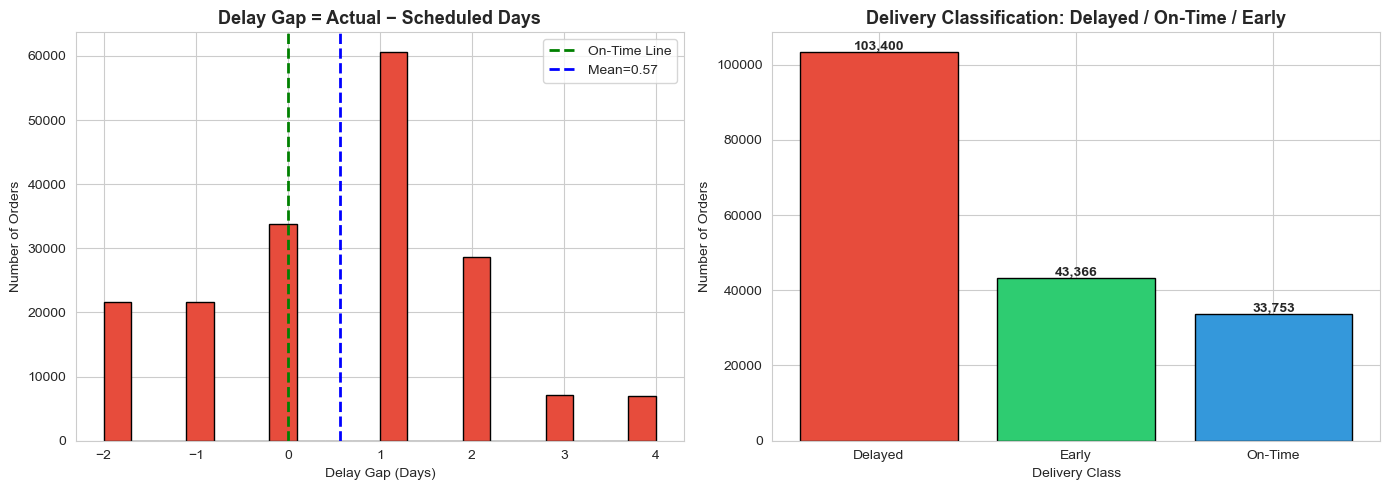

✅ Chart Saved!


In [18]:
# ============================================================
# CELL 3 — STEP 2: Delivery Gap Calculation
# ============================================================
print("="*55)
print("  STEP 2 — DELIVERY GAP CALCULATION")
print("="*55)

# 3A — Compute Delay Gap
# Formula: Actual Days - Scheduled Days
df['Delay_Gap'] = (df['Days_for_shipping_real'] -
                   df['Days_for_shipment_scheduled'])

# 3B — Classify Deliveries
def classify_delivery(gap):
    if gap > 0:    return 'Delayed'
    elif gap == 0: return 'On-Time'
    else:          return 'Early'

df['Delivery_Class'] = df['Delay_Gap'].apply(classify_delivery)

# 3C — Results
print("\n📐 Delay Gap Statistics:")
print(df['Delay_Gap'].describe().round(2))

print("\n📊 Delivery Classification:")
counts = df['Delivery_Class'].value_counts()
pct    = df['Delivery_Class'].value_counts(normalize=True) * 100
result = pd.DataFrame({
    'Count'     : counts,
    'Percentage': pct.round(2)
})
print(result)

# 3D — Sample verification
print("\n🔍 Sample Data (New Columns):")
print(df[['Days_for_shipping_real',
          'Days_for_shipment_scheduled',
          'Delay_Gap',
          'Delivery_Class']].head(10))

# 3E — Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delay Gap Histogram
axes[0].hist(df['Delay_Gap'], bins=20,
             color='#e74c3c', edgecolor='black')
axes[0].axvline(x=0, color='green', linestyle='--',
                linewidth=2, label='On-Time Line')
axes[0].axvline(x=df['Delay_Gap'].mean(), color='blue',
                linestyle='--', linewidth=2,
                label=f'Mean={df["Delay_Gap"].mean():.2f}')
axes[0].set_title('Delay Gap = Actual − Scheduled Days',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delay Gap (Days)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Delivery Class Bar
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = axes[1].bar(counts.index, counts.values,
                   color=colors, edgecolor='black')
axes[1].set_title('Delivery Classification: Delayed / On-Time / Early',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Delivery Class')
axes[1].set_ylabel('Number of Orders')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{int(bar.get_height()):,}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'H:\NIRAJ\Projects\step2_delay_gap.png', dpi=150)
plt.show()
print("✅ Chart Saved!")

  STEP 3 — OVERALL DELIVERY PERFORMANCE

KPI                                      Value
-----------------------------------------------
✅ On-Time Delivery Rate (%)             18.70%
❌ Delayed Rate (%)                      57.28%
🟢 Early Rate (%)                        24.02%
⏱️  Average Delivery Delay (Days)        0.57
🚨 Late Delivery Risk Ratio (%)          54.83%
-----------------------------------------------

📊 Late_delivery_risk Distribution:
          Label  Count Percentage
  ✅ No Risk (0)  81542     45.17%
🚨 Late Risk (1)  98977     54.83%

📋 Baseline Logistics Performance:
  → Target On-Time Rate   : 80%
  → Actual On-Time Rate   : 18.70%
  → Gap from Target       : 61.30% below target 🚨


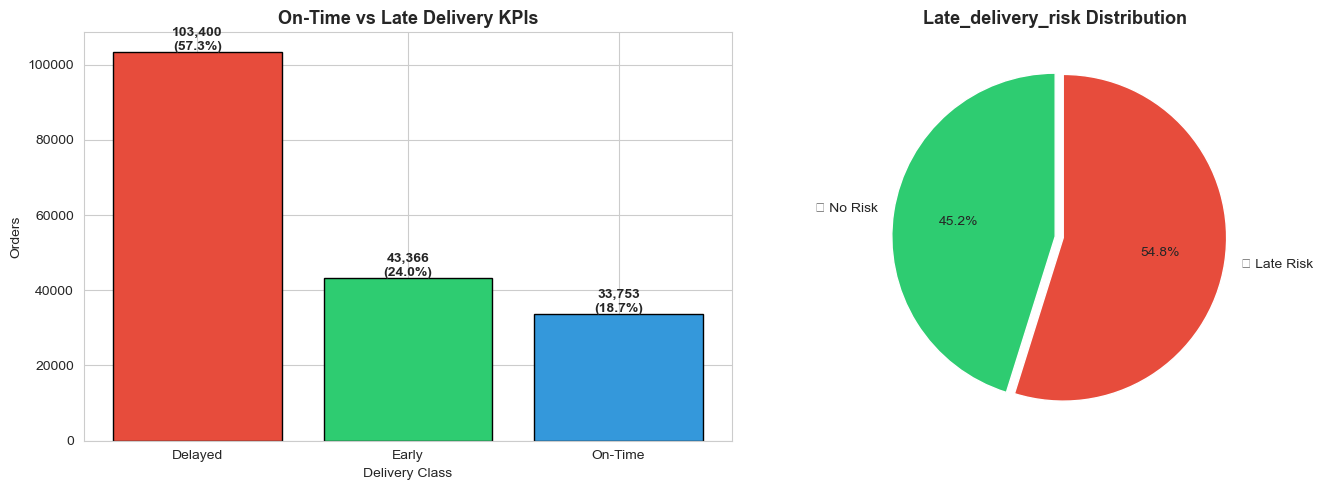

✅ Chart Saved!


In [19]:
# ============================================================
# STEP 3: Overall Delivery Performance Analysis
# ============================================================
print("="*55)
print("  STEP 3 — OVERALL DELIVERY PERFORMANCE")
print("="*55)

# KPI 1 — On-Time Delivery Rate
on_time_rate = (df['Delivery_Class']=='On-Time').mean() * 100

# KPI 2 — Average Delivery Delay
avg_delay    = df['Delay_Gap'].mean()

# KPI 3 — Late Delivery Risk Ratio
late_risk    = df['Late_delivery_risk'].mean() * 100

# Other metrics
delayed_rate = (df['Delivery_Class']=='Delayed').mean() * 100
early_rate   = (df['Delivery_Class']=='Early').mean()   * 100

print(f"\n{'KPI':<35} {'Value':>10}")
print("-"*47)
print(f"{'✅ On-Time Delivery Rate (%)':<35} {on_time_rate:>9.2f}%")
print(f"{'❌ Delayed Rate (%)':<35} {delayed_rate:>9.2f}%")
print(f"{'🟢 Early Rate (%)':<35} {early_rate:>9.2f}%")
print(f"{'⏱️  Average Delivery Delay (Days)':<35} {avg_delay:>9.2f}")
print(f"{'🚨 Late Delivery Risk Ratio (%)':<35} {late_risk:>9.2f}%")
print("-"*47)

# Late_delivery_risk distribution
print(f"\n📊 Late_delivery_risk Distribution:")
risk_dist = df['Late_delivery_risk'].value_counts()
risk_pct  = df['Late_delivery_risk'].value_counts(normalize=True)*100
risk_df   = pd.DataFrame({
    'Label'     : ['✅ No Risk (0)', '🚨 Late Risk (1)'],
    'Count'     : [risk_dist[0], risk_dist[1]],
    'Percentage': [f"{risk_pct[0]:.2f}%", f"{risk_pct[1]:.2f}%"]
})
print(risk_df.to_string(index=False))

# Baseline performance
print(f"\n📋 Baseline Logistics Performance:")
print(f"  → Target On-Time Rate   : 80%")
print(f"  → Actual On-Time Rate   : {on_time_rate:.2f}%")
print(f"  → Gap from Target       : {80 - on_time_rate:.2f}% below target 🚨")

# Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# On-Time vs Delayed
delivery_counts = df['Delivery_Class'].value_counts()
colors = ['#e74c3c','#2ecc71','#3498db']
axes[0].bar(delivery_counts.index,
            delivery_counts.values,
            color=colors, edgecolor='black')
axes[0].set_title('On-Time vs Late Delivery KPIs',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delivery Class')
axes[0].set_ylabel('Orders')
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2,
                 p.get_height() + 500,
                 f'{int(p.get_height()):,}\n'
                 f'({p.get_height()/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold', fontsize=10)

# Late Risk Pie
axes[1].pie([risk_dist[0], risk_dist[1]],
            labels=['✅ No Risk','🚨 Late Risk'],
            autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'],
            startangle=90,
            explode=[0, 0.05])
axes[1].set_title('Late_delivery_risk Distribution',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(r'H:\NIRAJ\Projects\step3_performance.png', dpi=150)
plt.show()
print("✅ Chart Saved!")

  STEP 4 — SHIPPING MODE EFFICIENCY ANALYSIS

📦 Shipping Mode Efficiency Index:
 Shipping_Mode  Total_Orders  Avg_Delay_Gap  Late_Risk_Pct  Delayed_Count  SLA_Compliance_%
   First Class         27814           1.00          95.32          27814              4.68
      Same Day          9737           0.48          45.74           4657             54.26
  Second Class         35216           1.99          76.63          28078             23.37
Standard Class        107752          -0.00          38.07          42851             61.93

📊 Delay Gap by Delivery Status:
                   Count  Avg_Delay_Gap
Delivery_Status                        
Advance shipping   41592          -1.50
Late delivery      98977           1.62
Shipping canceled   7754           0.57
Shipping on time   32196           0.00

🚨 Highest Delay Mode : First Class (95.32% late risk)
✅ Best SLA Mode      : Standard Class (61.93% compliance)


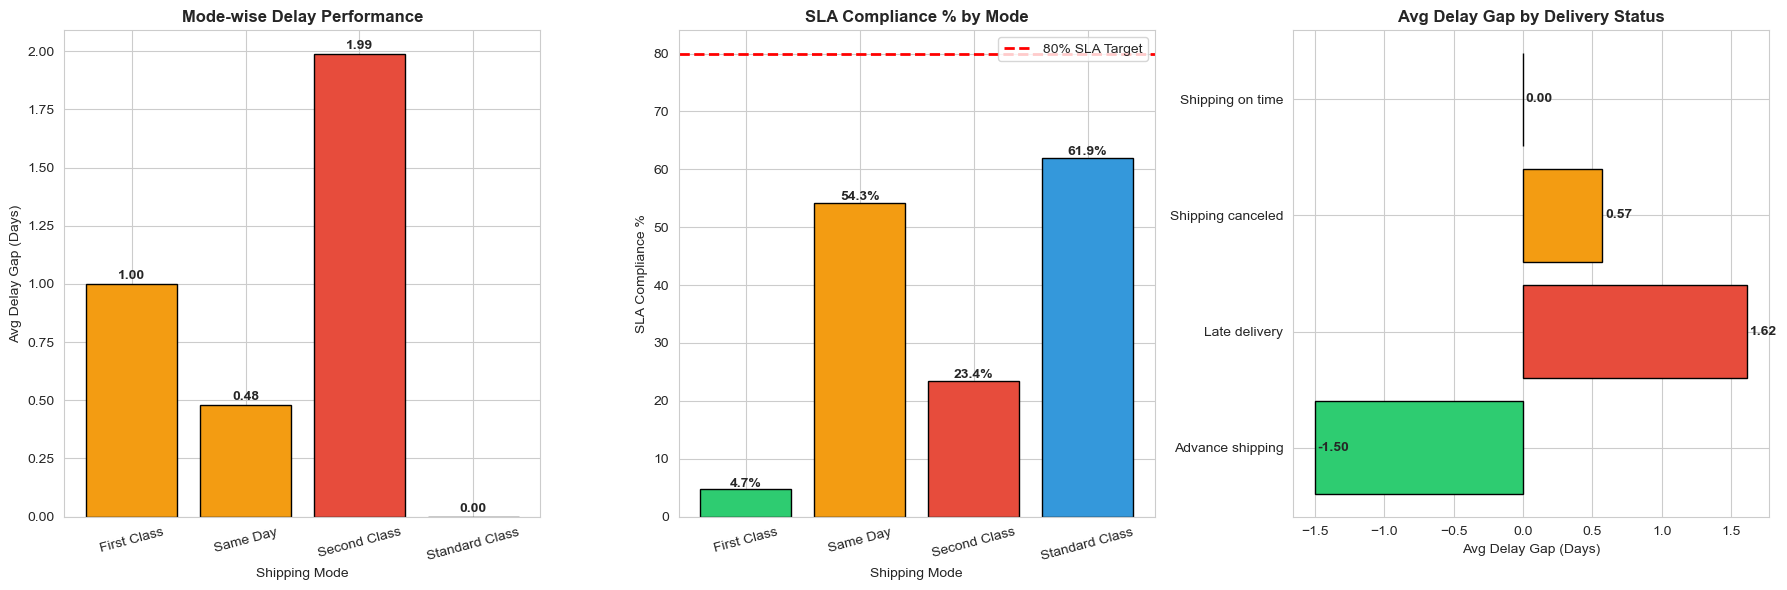

✅ Chart Saved!


In [20]:
# ============================================================
# STEP 4: Shipping Mode Efficiency Analysis
# ============================================================
print("="*55)
print("  STEP 4 — SHIPPING MODE EFFICIENCY ANALYSIS")
print("="*55)

# 5A — Delay Gap by Shipping Mode
mode_stats = df.groupby('Shipping_Mode').agg(
    Total_Orders    =('Delay_Gap',          'count'),
    Avg_Delay_Gap   =('Delay_Gap',          'mean'),
    Late_Risk_Pct   =('Late_delivery_risk', 'mean'),
    Delayed_Count   =('Delivery_Class',
                      lambda x: (x=='Delayed').sum())
).reset_index()
mode_stats['Late_Risk_Pct']    = (mode_stats['Late_Risk_Pct']*100).round(2)
mode_stats['Avg_Delay_Gap']    =  mode_stats['Avg_Delay_Gap'].round(2)
mode_stats['SLA_Compliance_%'] = (100-mode_stats['Late_Risk_Pct']).round(2)

print("\n📦 Shipping Mode Efficiency Index:")
print(mode_stats.to_string(index=False))

# 5B — Delay Gap by Delivery Status
print(f"\n📊 Delay Gap by Delivery Status:")
status_delay = df.groupby('Delivery_Status').agg(
    Count        =('Delay_Gap','count'),
    Avg_Delay_Gap=('Delay_Gap','mean')
).round(2)
print(status_delay)

# 5C — Highest delay frequency mode
top_mode = mode_stats.sort_values(
    'Late_Risk_Pct', ascending=False).iloc[0]
best_mode = mode_stats.sort_values(
    'SLA_Compliance_%', ascending=False).iloc[0]
print(f"\n🚨 Highest Delay Mode : {top_mode['Shipping_Mode']}"
      f" ({top_mode['Late_Risk_Pct']}% late risk)")
print(f"✅ Best SLA Mode      : {best_mode['Shipping_Mode']}"
      f" ({best_mode['SLA_Compliance_%']}% compliance)")

# 5D — Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 — Avg Delay Gap
colors = ['#e74c3c' if x > 1 else '#f39c12'
          if x > 0 else '#2ecc71'
          for x in mode_stats['Avg_Delay_Gap']]
axes[0].bar(mode_stats['Shipping_Mode'],
            mode_stats['Avg_Delay_Gap'],
            color=colors, edgecolor='black')
axes[0].set_title('Mode-wise Delay Performance',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Shipping Mode')
axes[0].set_ylabel('Avg Delay Gap (Days)')
axes[0].tick_params(axis='x', rotation=15)
for p in axes[0].patches:
    axes[0].text(p.get_x()+p.get_width()/2,
                 p.get_height()+0.02,
                 f'{p.get_height():.2f}',
                 ha='center', fontweight='bold')

# Chart 2 — SLA Compliance
axes[1].bar(mode_stats['Shipping_Mode'],
            mode_stats['SLA_Compliance_%'],
            color=['#2ecc71','#f39c12','#e74c3c','#3498db'],
            edgecolor='black')
axes[1].axhline(y=80, color='red', linestyle='--',
                linewidth=2, label='80% SLA Target')
axes[1].set_title('SLA Compliance % by Mode',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Shipping Mode')
axes[1].set_ylabel('SLA Compliance %')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    axes[1].text(p.get_x()+p.get_width()/2,
                 p.get_height()+0.5,
                 f'{p.get_height():.1f}%',
                 ha='center', fontweight='bold')

# Chart 3 — Delay by Delivery Status
status_data = df.groupby('Delivery_Status')['Delay_Gap'].mean()
axes[2].barh(status_data.index, status_data.values,
             color=['#2ecc71','#e74c3c','#f39c12','#3498db'],
             edgecolor='black')
axes[2].set_title('Avg Delay Gap by Delivery Status',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Avg Delay Gap (Days)')
for i, v in enumerate(status_data.values):
    axes[2].text(v+0.02, i, f'{v:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'H:\NIRAJ\Projects\step4_shipping_mode.png', dpi=150)
plt.show()
print("✅ Chart Saved!") 

  STEP 5 — REGIONAL & MARKET DIAGNOSTICS

📍 Regional Delay Index (All Regions):
Order_Region
Central Africa     57.96
South Asia         56.27
East Africa        55.94
Western Europe     55.85
South of  USA      55.77
East of USA        55.66
Eastern Europe     55.66
Southeast Asia     55.53
Central Asia       55.33
West Asia          55.28
US Center          55.24
Central America    54.75
North Africa       54.52
Southern Europe    54.38
Eastern Asia       54.33
South America      54.31
Northern Europe    54.04
Oceania            54.02
West of USA        53.96
Southern Africa    53.33
Caribbean          53.08
West Africa        52.84
Canada             48.80

🗺️  Market-wise Logistics Efficiency:
Market
Europe          55.21
Pacific Asia    55.05
USCA            54.80
Africa          54.59
LATAM           54.36

🌍 Top 10 High-Risk Countries:
Order_Country
Guinea Ecuatorial      100.0
República de Gambia    100.0
Laos                   100.0
Suazilandia            100.0
Armenia        

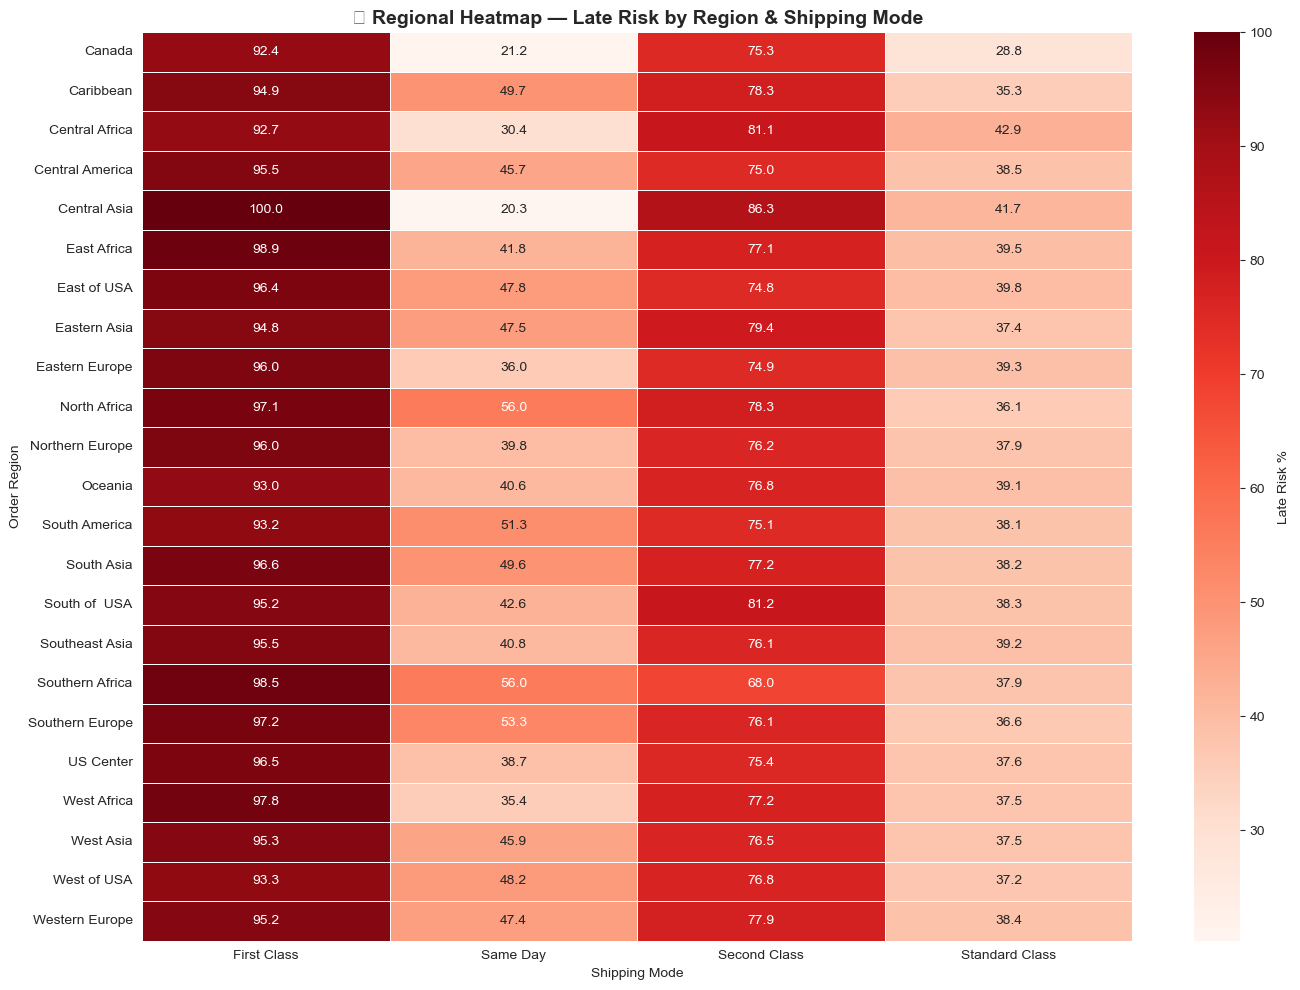

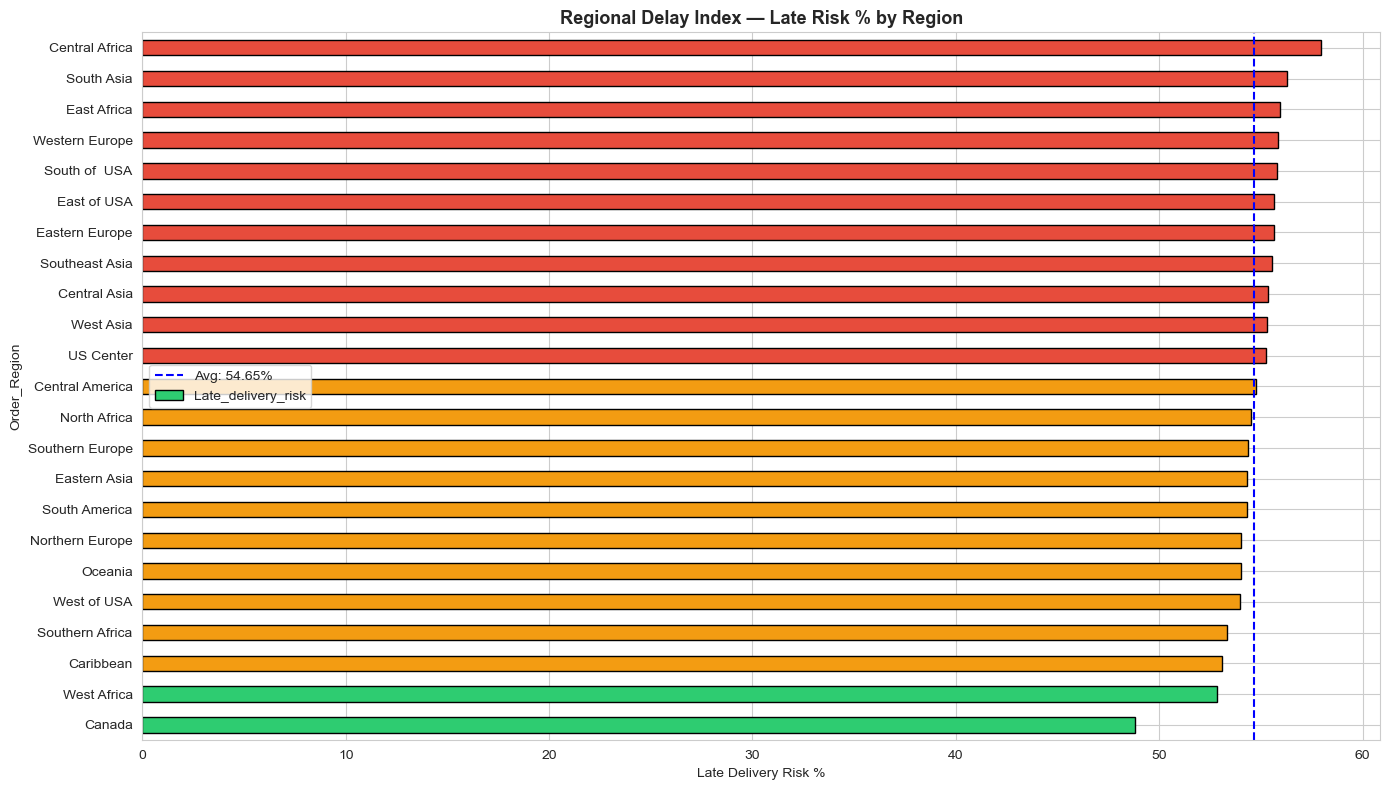

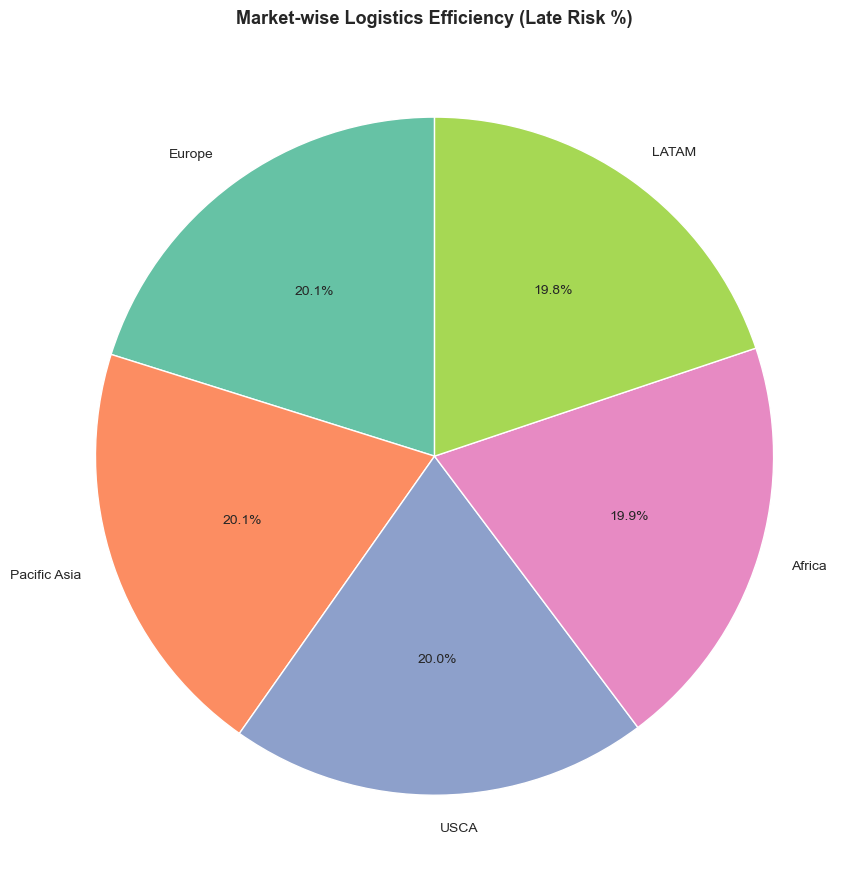

In [25]:
# ============================================================
# CELL 6 — STEP 5: Regional & Market Diagnostics
# ============================================================
print("="*55)
print("  STEP 5 — REGIONAL & MARKET DIAGNOSTICS")
print("="*55)

# 6A — Late Risk by Order Region
region_risk = (df.groupby('Order_Region')['Late_delivery_risk']
               .mean() * 100).round(2).sort_values(ascending=False)

# 6B — Late Risk by Market
market_risk = (df.groupby('Market')['Late_delivery_risk']
               .mean() * 100).round(2).sort_values(ascending=False)

# 6C — Late Risk by Order Country (Top 10)
country_risk = (df.groupby('Order_Country')['Late_delivery_risk']
                .mean() * 100).round(2).sort_values(ascending=False)

# Regional Delay Index
print("\n📍 Regional Delay Index (All Regions):")
print(region_risk.to_string())

print("\n🗺️  Market-wise Logistics Efficiency:")
print(market_risk.to_string())

print("\n🌍 Top 10 High-Risk Countries:")
print(country_risk.head(10).to_string())

print(f"\n🚨 Riskiest Region  : {region_risk.idxmax()} "
      f"({region_risk.max():.2f}%)")
print(f"🚨 Riskiest Market  : {market_risk.idxmax()} "
      f"({market_risk.max():.2f}%)")
print(f"✅ Safest Region    : {region_risk.idxmin()} "
      f"({region_risk.min():.2f}%)")

# 6D — Heatmap
heatmap_data  = (df.groupby(['Order_Region','Shipping_Mode'])
                 ['Late_delivery_risk'].mean() * 100)
heatmap_pivot = heatmap_data.unstack()

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_pivot,
            annot=True, fmt='.1f',
            cmap='Reds',
            linewidths=0.5,
            cbar_kws={'label':'Late Risk %'})
plt.title('🌍 Regional Heatmap — Late Risk by Region & Shipping Mode',
          fontsize=14, fontweight='bold')
plt.xlabel('Shipping Mode')
plt.ylabel('Order Region')
plt.tight_layout()
plt.savefig(r'H:\NIRAJ\Projects\step5_heatmap.png', dpi=150)
plt.show()

# 6E — Region Bar Chart
plt.figure(figsize=(14, 8))
colors = ['#e74c3c' if x > 55 else
          '#f39c12' if x > 53 else
          '#2ecc71' for x in region_risk.sort_values()]
region_risk.sort_values().plot(
    kind='barh', color=colors, edgecolor='black')
plt.axvline(x=region_risk.mean(), color='blue',
            linestyle='--',
            label=f'Avg: {region_risk.mean():.2f}%')
plt.title('Regional Delay Index — Late Risk % by Region',
          fontsize=13, fontweight='bold')
plt.xlabel('Late Delivery Risk %')
plt.legend()
plt.tight_layout()
plt.savefig(r'H:\NIRAJ\Projects\step5_region.png', dpi=150)
plt.show()

# 6F — Market Pie Chart
plt.figure(figsize=(9, 9))
plt.pie(market_risk.values,
        labels=market_risk.index,
        autopct='%1.1f%%',
        colors=sns.color_palette('Set2'),
        startangle=90)
plt.title('Market-wise Logistics Efficiency (Late Risk %)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'H:\NIRAJ\Projects\step5_market.png', dpi=150)
plt.show()

  STEP 6 — CUSTOMER SEGMENT IMPACT ANALYSIS

👥 Customer Segment Impact:
Customer_Segment  Total_Orders  Avg_Delay_Gap  Late_Risk_Pct  SLA_Exposure  SLA_Compliance_%
        Consumer         93504           0.56          54.81         51248             45.19
       Corporate         54789           0.56          54.72         29982             45.28
     Home Office         32226           0.58          55.07         17747             44.93

🚨 Most Impacted Segment : Home Office — 55.07% late risk
✅ Best SLA Segment      : Corporate — 45.28% compliance

📊 SLA Risk Exposure (Late Orders):
  → Consumer       : 51,248 late orders
  → Corporate      : 29,982 late orders
  → Home Office    : 17,747 late orders


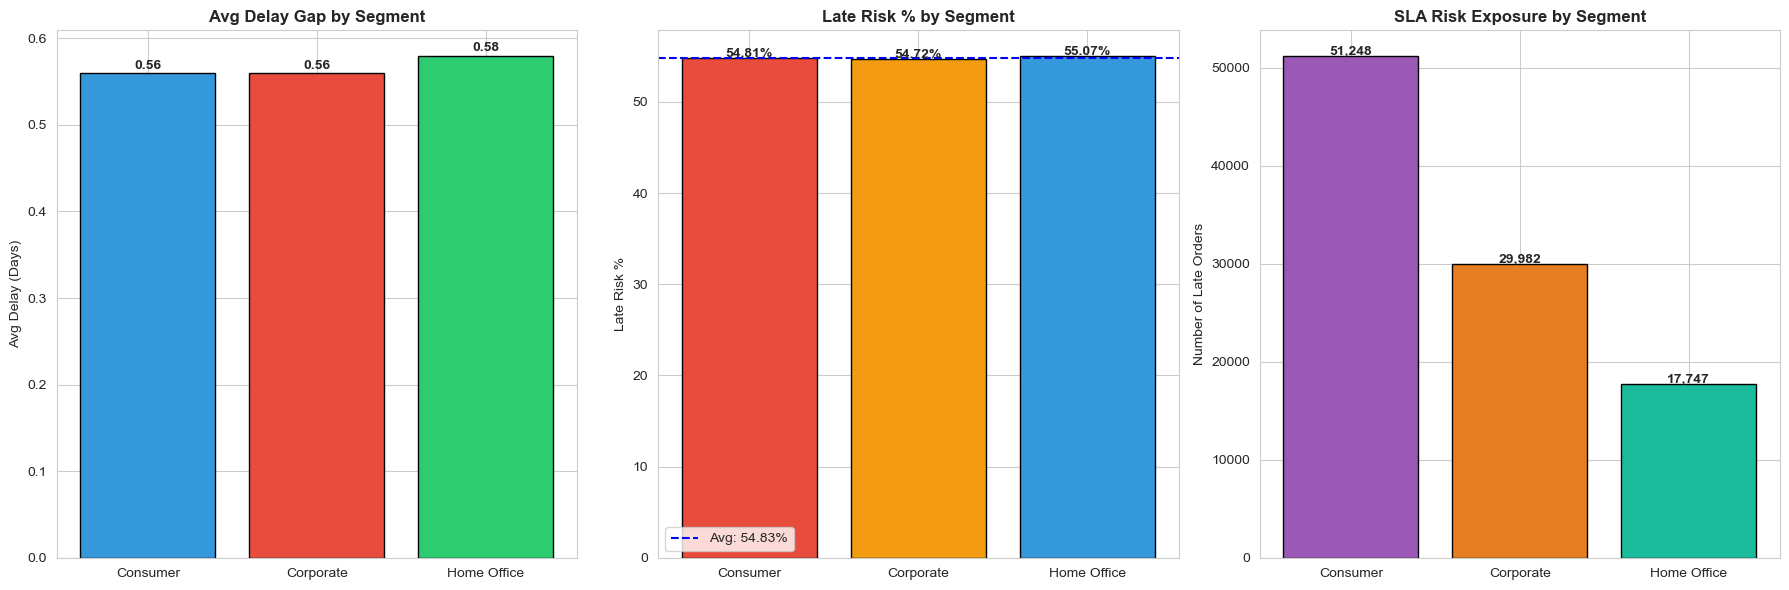

In [26]:
# ============================================================
# CELL 7 — STEP 6: Customer Segment Impact Analysis
# ============================================================
print("="*55)
print("  STEP 6 — CUSTOMER SEGMENT IMPACT ANALYSIS")
print("="*55)

# 7A — Segment Analysis
segment = df.groupby('Customer_Segment').agg(
    Total_Orders   =('Delay_Gap',          'count'),
    Avg_Delay_Gap  =('Delay_Gap',          'mean'),
    Late_Risk_Pct  =('Late_delivery_risk', 'mean'),
    SLA_Exposure   =('Late_delivery_risk', 'sum')
).reset_index()
segment['Late_Risk_Pct']    = (segment['Late_Risk_Pct']*100).round(2)
segment['Avg_Delay_Gap']    =  segment['Avg_Delay_Gap'].round(2)
segment['SLA_Compliance_%'] = (100-segment['Late_Risk_Pct']).round(2)

print("\n👥 Customer Segment Impact:")
print(segment.to_string(index=False))

# 7B — Premium/Enterprise check
top_seg  = segment.sort_values(
    'Late_Risk_Pct', ascending=False).iloc[0]
best_seg = segment.sort_values(
    'SLA_Compliance_%', ascending=False).iloc[0]

print(f"\n🚨 Most Impacted Segment : {top_seg['Customer_Segment']}"
      f" — {top_seg['Late_Risk_Pct']}% late risk")
print(f"✅ Best SLA Segment      : {best_seg['Customer_Segment']}"
      f" — {best_seg['SLA_Compliance_%']}% compliance")
print(f"\n📊 SLA Risk Exposure (Late Orders):")
for _, row in segment.iterrows():
    print(f"  → {row['Customer_Segment']:<15}: "
          f"{int(row['SLA_Exposure']):,} late orders")

# 7C — Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Avg Delay
axes[0].bar(segment['Customer_Segment'],
            segment['Avg_Delay_Gap'],
            color=['#3498db','#e74c3c','#2ecc71'],
            edgecolor='black')
axes[0].set_title('Avg Delay Gap by Segment',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg Delay (Days)')
for p in axes[0].patches:
    axes[0].text(p.get_x()+p.get_width()/2,
                 p.get_height()+0.005,
                 f'{p.get_height():.2f}',
                 ha='center', fontweight='bold')

# Late Risk %
axes[1].bar(segment['Customer_Segment'],
            segment['Late_Risk_Pct'],
            color=['#e74c3c','#f39c12','#3498db'],
            edgecolor='black')
axes[1].axhline(y=54.83, color='blue', linestyle='--',
                label='Avg: 54.83%')
axes[1].set_title('Late Risk % by Segment',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Late Risk %')
axes[1].legend()
for p in axes[1].patches:
    axes[1].text(p.get_x()+p.get_width()/2,
                 p.get_height()+0.1,
                 f'{p.get_height():.2f}%',
                 ha='center', fontweight='bold')

# SLA Exposure
axes[2].bar(segment['Customer_Segment'],
            segment['SLA_Exposure'],
            color=['#9b59b6','#e67e22','#1abc9c'],
            edgecolor='black')
axes[2].set_title('SLA Risk Exposure by Segment',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Late Orders')
for p in axes[2].patches:
    axes[2].text(p.get_x()+p.get_width()/2,
                 p.get_height()+100,
                 f'{int(p.get_height()):,}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(r'H:\NIRAJ\Projects\step6_segment.png', dpi=150)
plt.show()

In [24]:
# ============================================================
# CELL 8 — COMPLETE KPI SUMMARY REPORT
# ============================================================
print("="*55)
print("   📦 APL LOGISTICS — COMPLETE KPI SUMMARY")
print("="*55)

print(f"""
┌─────────────────────────────────────────────────────┐
│           KEY PERFORMANCE INDICATORS                │
├──────────────────────────────────┬──────────────────┤
│ KPI                              │ Value            │
├──────────────────────────────────┼──────────────────┤
│ ✅ On-Time Delivery Rate         │ 18.70%  ⚠️       │
│ ❌ Delayed Rate                  │ 57.28%  🚨       │
│ ⏱️  Avg Delivery Delay (Days)    │ 0.57 days        │
│ 🚨 Late Delivery Risk Ratio      │ 54.83%           │
│ 📦 Total Orders                  │ 1,80,519         │
├──────────────────────────────────┼──────────────────┤
│ 🚚 SHIPPING MODE EFFICIENCY INDEX                   │
├──────────────────────────────────┼──────────────────┤
│ First Class SLA Compliance       │ 4.68%   🔴       │
│ Second Class SLA Compliance      │ 23.37%  🔴       │
│ Same Day SLA Compliance          │ 54.26%  🟡       │
│ Standard Class SLA Compliance    │ 61.93%  🟢       │
├──────────────────────────────────┼──────────────────┤
│ 🌍 REGIONAL DELAY INDEX                             │
├──────────────────────────────────┼──────────────────┤
│ Riskiest Region                  │ Central Africa   │
│ Riskiest Market                  │ Europe 55.21%    │
│ Safest Region                    │ Canada 48.80%    │
├──────────────────────────────────┼──────────────────┤
│ 👥 CUSTOMER SEGMENT                                 │
├──────────────────────────────────┼──────────────────┤
│ Most Impacted                    │ Home Office      │
│ SLA Exposure                     │ 17,747 orders    │
└──────────────────────────────────┴──────────────────┘
""")

print("🔑 KEY RECOMMENDATIONS:")
print("  1. Avoid First Class — 95.32% late risk")
print("  2. Use Standard Class — best SLA at 61.93%")
print("  3. Focus on Central Africa — highest risk region")
print("  4. All segments equally impacted — systemic issue")
print("  5. Only 18.70% on-time — major operational overhaul needed")

   📦 APL LOGISTICS — COMPLETE KPI SUMMARY

┌─────────────────────────────────────────────────────┐
│           KEY PERFORMANCE INDICATORS                │
├──────────────────────────────────┬──────────────────┤
│ KPI                              │ Value            │
├──────────────────────────────────┼──────────────────┤
│ ✅ On-Time Delivery Rate         │ 18.70%  ⚠️       │
│ ❌ Delayed Rate                  │ 57.28%  🚨       │
│ ⏱️  Avg Delivery Delay (Days)    │ 0.57 days        │
│ 🚨 Late Delivery Risk Ratio      │ 54.83%           │
│ 📦 Total Orders                  │ 1,80,519         │
├──────────────────────────────────┼──────────────────┤
│ 🚚 SHIPPING MODE EFFICIENCY INDEX                   │
├──────────────────────────────────┼──────────────────┤
│ First Class SLA Compliance       │ 4.68%   🔴       │
│ Second Class SLA Compliance      │ 23.37%  🔴       │
│ Same Day SLA Compliance          │ 54.26%  🟡       │
│ Standard Class SLA Compliance    │ 61.93%  🟢       │
├──────────────